# LSTM Demand Forecasting Model  
스케일링 + 슬라이딩 윈도우 + 개선된 LSTM 구조를 활용한 수요 예측 모델입니다.

### 포함 기능
- StandardScaler 기반 Feature Scaling
- Sliding Window Sequence 생성
- Train / Validation 시계열 분리
- Dropout 포함 LSTM 모델
- 예측값 inverse scaling
- RMSE / MAE / MAPE / 시각화

---

In [2]:
# ===============================================================
# 1. Import & Configuration
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# User settings
# -----------------------------
DATASET_VERSION = 2
WINDOW_SIZE = 12
BATCH_SIZE = 32
EPOCHS = 200
PATIENCE = 20

FEATURE_CONFIGS = {
    1: {
        "file": "../data/final_features_1.csv",
        "features": [
            "platt_apag_mom_pct", "platt_crude_mom_pct", "temp_avg", "precip_avg",
            "threshold_temp_days", "threshold_rainy_days",
            "possible_working_days", "avg_weight"
        ],
        "name": "final_features_1.csv"
    },
    2: {
        "file": "../data/final_features_2.csv",
        "features": [
            "season_sin", "season_cos", "temp_avg", "precip_avg",
            "possible_working_days", "avg_weight",
            "ap_price_weight", "crude_price_weight"
        ],
        "name": "final_features_2.csv"
    }
}

# 2. Load Data  
CSV을 읽어 날짜 변환 및 정렬을 수행합니다.

In [3]:
# ===============================================================
# 2. Load Data
# ===============================================================
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config["file"])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)

feature_cols = config["features"]
df = df.sort_values("ds").reset_index(drop=True)

df["demand"] = df["demand"].astype(float)
for col in feature_cols:
    df[col] = df[col].astype(float)

print("Dataset:", config["name"])
df.head()

Dataset: final_features_2.csv


,date,demand,quarter,season_sin,season_cos,temp_avg,precip_avg,possible_working_days,avg_weight,ap_price_weight,crude_price_weight,ds
0,200101,18786.0,1,0.500000,8.660254e-01,-2.617516,2.119862,15.0,0.0340,146683.833333,144764.166667,2001-01-31
1,200102,31063.0,1,0.866025,5.000000e-01,0.583643,3.207810,20.0,0.0359,146683.833333,144764.166667,2001-02-28
2,200103,95192.0,1,1.000000,6.123234e-17,5.205774,0.903880,22.0,0.0679,146683.833333,144764.166667,2001-03-31
3,200104,161437.0,2,0.866025,-5.000000e-01,12.494833,2.184500,21.0,0.0913,146683.833333,144764.166667,2001-04-30
4,200105,176527.0,2,0.500000,-8.660254e-01,18.081581,2.028333,23.0,0.1065,146683.833333,144764.166667,2001-05-31


# 3. Scaling  
LSTM 안정적 학습을 위해 Feature / Target 모두 StandardScaler 적용.

In [4]:
# ===============================================================
# 3. Scaling (CRITICAL for LSTM)
# ===============================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_raw = df[feature_cols].values
y_raw = df[["demand"]].values

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

print("Scaling complete.")

Scaling complete.


# 4. Sliding Window 생성  
LSTM 입력 형태 [Window, Feature] 를 만들기 위해 시퀀스 생성.

In [5]:
# ===============================================================
# 4. Create Sliding Window Sequences
# ===============================================================
X_seq = []
y_seq = []
ds_seq = []

for t in range(WINDOW_SIZE, len(df)):
    X_seq.append(X_scaled[t-WINDOW_SIZE:t])
    y_seq.append(y_scaled[t])
    ds_seq.append(df["ds"][t])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).reshape(-1, 1)
ds_seq = np.array(ds_seq)

print("Total sequences:", len(X_seq))
print("Input shape:", X_seq.shape)

Total sequences: 284
Input shape: (284, 12, 8)


# 5. Train / Validation Split  
마지막 32개월을 Validation 데이터로 사용합니다.

In [6]:
# ===============================================================
# 5. Train / Valid Split (time-based)
# ===============================================================
cutoff = df["ds"].max() - pd.DateOffset(months=32)

train_mask = ds_seq <= cutoff
valid_mask = ds_seq > cutoff

X_train = X_seq[train_mask]
y_train = y_seq[train_mask]
ds_train = ds_seq[train_mask]

X_valid = X_seq[valid_mask]
y_valid = y_seq[valid_mask]
ds_valid = ds_seq[valid_mask]

print("Train samples:", X_train.shape[0])
print("Valid samples:", X_valid.shape[0])
print("Date range:", ds_train[0], "~", ds_valid[-1])

Train samples: 252
Valid samples: 32
Date range: 2002-01-31 00:00:00 ~ 2025-08-31 00:00:00


# 6. Build Improved LSTM Model  
Dropout 포함 안정적 모델 구성.

In [7]:
# ===============================================================
# 6. Build LSTM Model (Improved architecture)
# ===============================================================
input_shape = (WINDOW_SIZE, len(feature_cols))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,961 (97.50 KB)

 Trainable params: 24,961 (97.50 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Train Model  
EarlyStopping 적용하여 과적합 방지.

In [8]:
# ===============================================================
# 7. Training with Early Stopping
# ===============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.9689 - val_loss: 0.8165
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8535 - val_loss: 0.7277
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7536 - val_loss: 0.6302
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6305 - val_loss: 0.4984
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4654 - val_loss: 0.3775
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3796 - val_loss: 0.3816
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3200 - val_loss: 0.3674
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2946 - val_loss: 0.3422
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2711 - val_loss: 0.3652
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2506 - val_loss: 0.3057
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2534 - val_loss: 0.3096
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2180 - val_loss: 0.3434


# 8. Predictions & Inverse Scaling  
모델 출력값을 원래 스케일로 되돌립니다.

In [9]:
# ===============================================================
# 8. Predictions (inverse scaled)
# ===============================================================
train_pred = scaler_y.inverse_transform(model.predict(X_train))
valid_pred = scaler_y.inverse_transform(model.predict(X_valid))

y_train_true = scaler_y.inverse_transform(y_train)
y_valid_true = scaler_y.inverse_transform(y_valid)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


# 9. Metrics  
RMSE / MAE / MAPE 계산.

In [ ]:
# ===============================================================
# 9. Metrics
# ===============================================================
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n[{label}]")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE:  {mae:,.0f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape}

train_metrics = evaluate(y_train_true, train_pred, "TRAIN")
valid_metrics = evaluate(y_valid_true, valid_pred, "VALID")

In [ ]:
# ===============================================================
# Save Results to JSON
# ===============================================================
import json
from datetime import datetime
import glob
import re

# Collect model parameters
lstm_params = {
    'window_size': WINDOW_SIZE,
    'lstm_units': 64,
    'dropout_rate': 0.2,
    'dense_layers': [64, 32],
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'optimizer': 'AdamW',
    'early_stopping_patience': PATIENCE,
    'epochs_trained': len(history.history['loss']),
    'best_epoch': len(history.history['loss']) - PATIENCE,
    'final_train_loss': float(history.history['loss'][-1]),
    'final_val_loss': float(history.history['val_loss'][-1])
}

# Check for duplicates
existing_files = glob.glob(f"../results/lstm_feature{DATASET_VERSION}_results_*.json")
params_exist = False
existing_run = None

for file in existing_files:
    try:
        with open(file, 'r') as f:
            existing_data = json.load(f)
            ep = existing_data.get('model_parameters', {})
            if (ep.get('window_size') == lstm_params['window_size'] and
                ep.get('lstm_units') == lstm_params['lstm_units'] and
                ep.get('batch_size') == lstm_params['batch_size'] and
                ep.get('learning_rate') == lstm_params['learning_rate'] and
                ep.get('dropout_rate') == lstm_params['dropout_rate']):
                params_exist = True
                existing_run = file
                break
    except:
        continue

if params_exist:
    print("\n" + "="*60)
    print("⚠️  RESULTS NOT SAVED - Parameters already exist")
    print(f"File: {existing_run}")
    print("="*60)
else:
    run_numbers = []
    for file in existing_files:
        match = re.search(rf'lstm_feature{DATASET_VERSION}_results_(\d+)\.json', file)
        if match:
            run_numbers.append(int(match.group(1)))
    
    next_run = max(run_numbers) + 1 if run_numbers else 1
    
    results = {
        "model_name": f"LSTM Standalone - {config['name']}",
        "model_type": "LSTM",
        "run_number": next_run,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": config['name'],
        "features": feature_cols,
        "num_features": len(feature_cols),
        "train_samples": len(X_train),
        "valid_samples": len(X_valid),
        "model_parameters": lstm_params,
        "metrics": {
            "training": {
                "rmse": float(train_metrics['rmse']),
                "mae": float(train_metrics['mae']),
                "mape": float(train_metrics['mape'])
            },
            "validation": {
                "rmse": float(valid_metrics['rmse']),
                "mae": float(valid_metrics['mae']),
                "mape": float(valid_metrics['mape'])
            }
        }
    }
    
    result_path = f"../results/lstm_feature{DATASET_VERSION}_results_{next_run}.json"
    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n" + "="*60)
    print(f"✅ Results saved to: {result_path}")
    print(f"Run number: {next_run}")
    print("="*60)

# 10. Visualization  
Loss curve · Actual vs Predicted

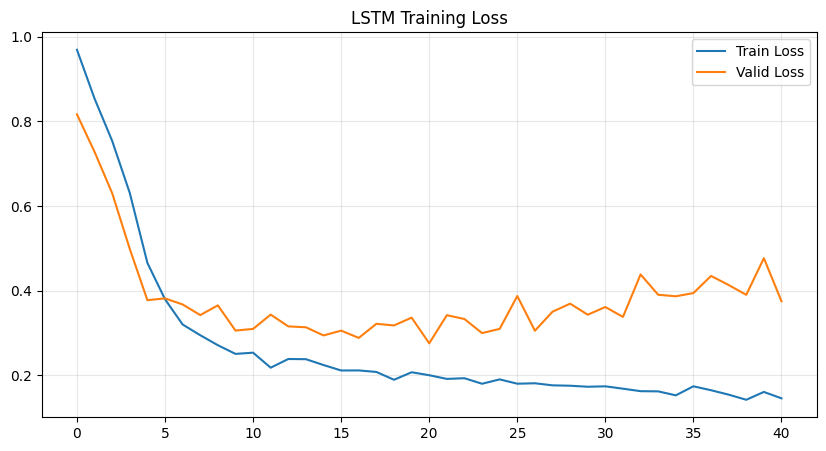

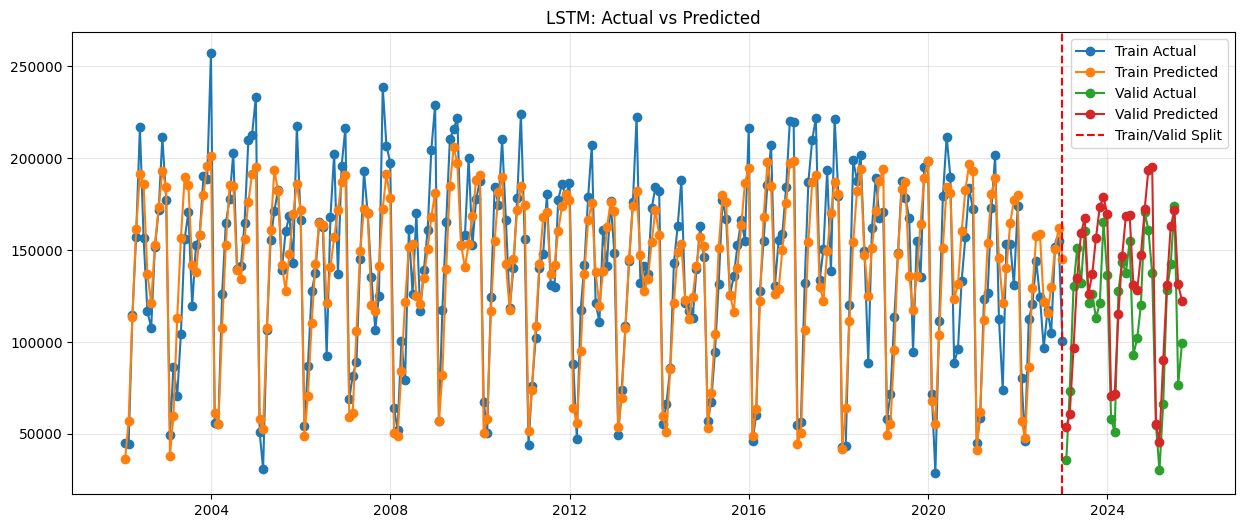

In [11]:
# ===============================================================
# 10. Visualization
# ===============================================================

# Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Valid Loss")
plt.title("LSTM Training Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(15,6))
plt.plot(ds_train, y_train_true, "o-", label="Train Actual")
plt.plot(ds_train, train_pred, "o-", label="Train Predicted")

plt.plot(ds_valid, y_valid_true, "o-", label="Valid Actual")
plt.plot(ds_valid, valid_pred, "o-", label="Valid Predicted")

plt.axvline(x=cutoff, color="red", linestyle="--", label="Train/Valid Split")
plt.title("LSTM: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 11. Save Model  
학습된 모델을 `.keras` 파일로 저장합니다.

In [12]:
# ===============================================================
# 11. Save Model
# ===============================================================
import os
os.makedirs("../models", exist_ok=True)
model.save(f"../models/lstm_standalone_feature{DATASET_VERSION}.keras")
print("Model saved.")

Model saved.
